Using device: cpu
Found classes: ['Anthracnose', 'Bacterial Wilt', 'Belly Rot', 'Downy Mildew', 'Fresh Cucumber', 'Fresh Leaf', 'Gummy Stem Blight', 'Pythium Fruit Rot']
Total samples: 1289
Train samples: 902, Val samples: 193, Test samples: 194
Model params: 525,064
Starting training...

Epoch 1/5


Training: 100%|██████████| 29/29 [00:49<00:00,  1.72s/it]


Train Loss: 1.5115, Train Acc: 39.25%
Val   Loss: 1.2842, Val   Acc: 49.22%
New best model saved (Val Acc: 49.22%)

Epoch 2/5


Training: 100%|██████████| 29/29 [00:41<00:00,  1.42s/it]


Train Loss: 1.1861, Train Acc: 52.66%
Val   Loss: 1.4566, Val   Acc: 47.15%
Early stopping counter: 1/5

Epoch 3/5


...

Train Loss: 1.0108, Train Acc: 62.42%
Val   Loss: 0.8731, Val   Acc: 56.99%
New best model saved (Val Acc: 56.99%)

Epoch 5/5


Training: 100%|██████████| 29/29 [00:42<00:00,  1.48s/it]


Train Loss: 0.9150, Train Acc: 66.52%
Val   Loss: 0.7803, Val   Acc: 61.14%
New best model saved (Val Acc: 61.14%)
Training finished in 252.42 seconds. Best Val Acc: 61.14%


Testing: 100%|██████████| 7/7 [00:07<00:00,  1.03s/it]



Test Accuracy: 71.13%

Generating evaluation reports...


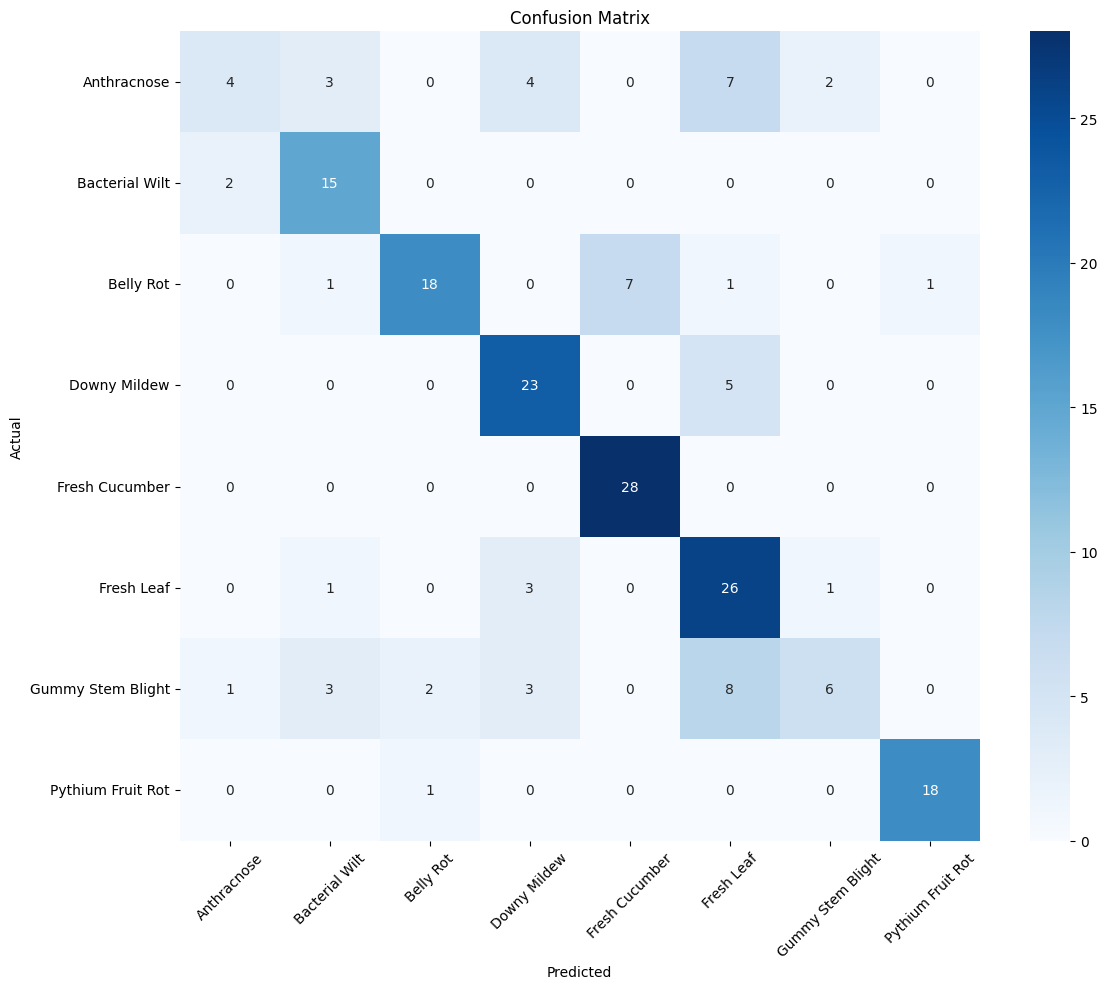


Classification Report:
                   precision    recall  f1-score   support

      Anthracnose       0.57      0.20      0.30        20
   Bacterial Wilt       0.65      0.88      0.75        17
        Belly Rot       0.86      0.64      0.73        28
     Downy Mildew       0.70      0.82      0.75        28
   Fresh Cucumber       0.80      1.00      0.89        28
       Fresh Leaf       0.55      0.84      0.67        31
Gummy Stem Blight       0.67      0.26      0.38        23
Pythium Fruit Rot       0.95      0.95      0.95        19

         accuracy                           0.71       194
        macro avg       0.72      0.70      0.68       194
     weighted avg       0.72      0.71      0.68       194



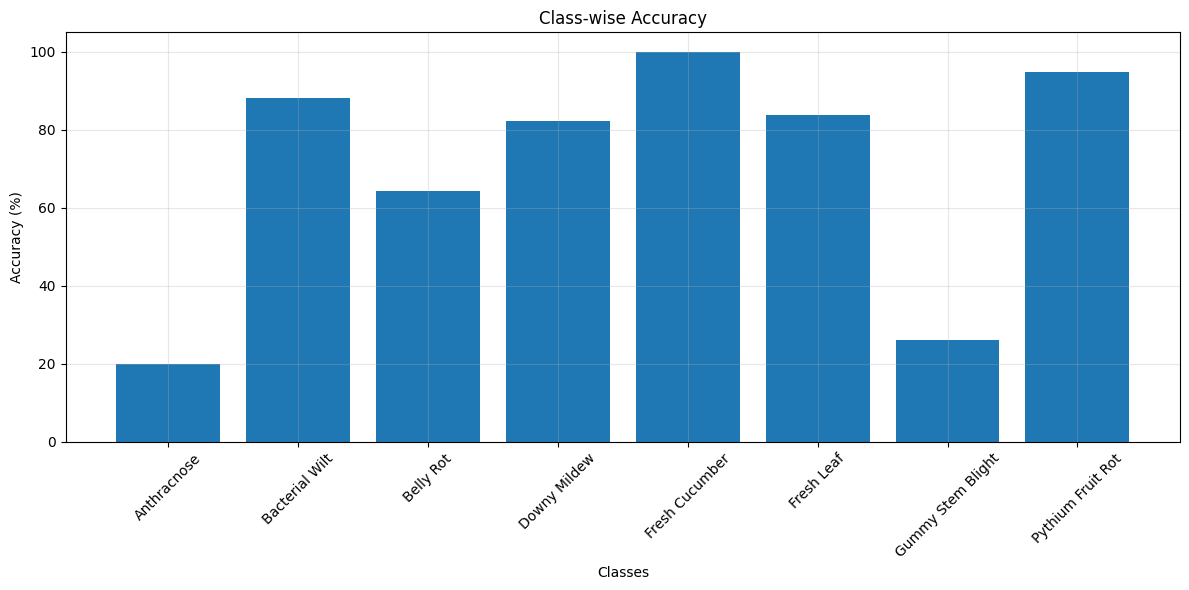

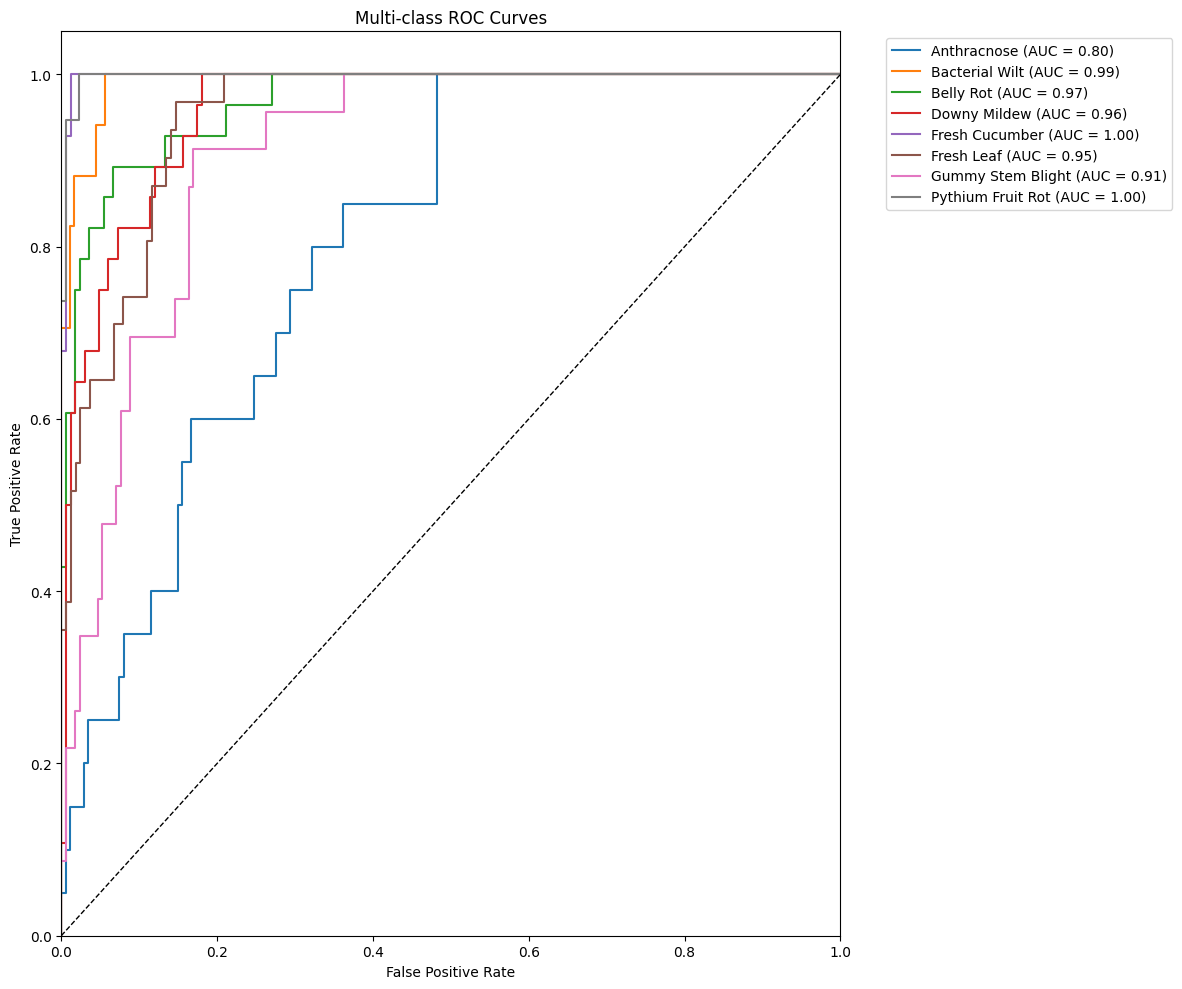

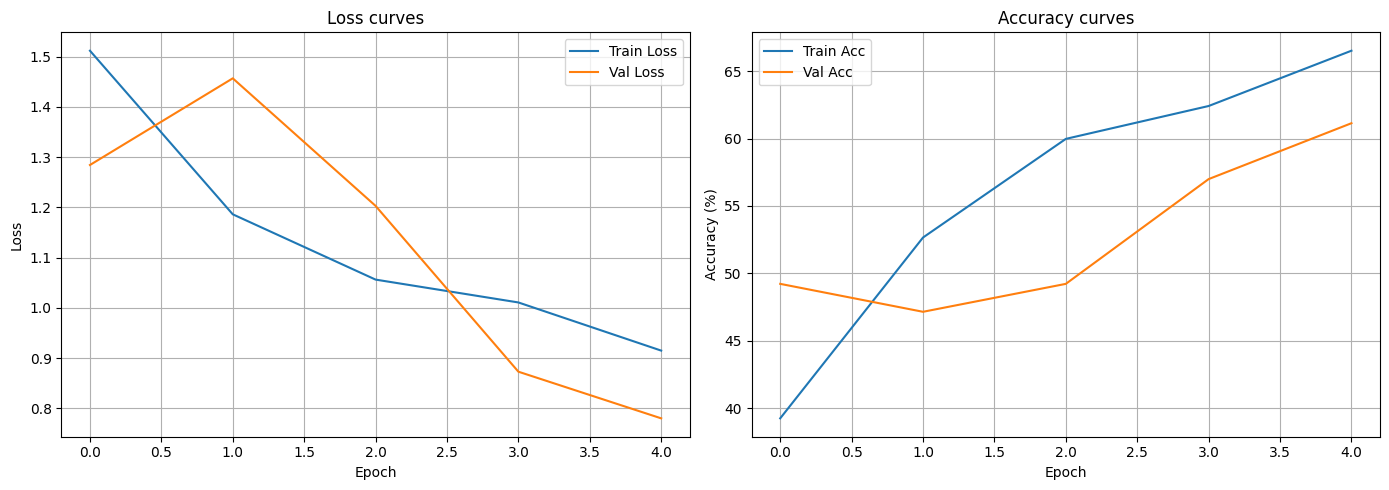


FINAL RESULTS SUMMARY - CUSTOM CNN MODEL
Training Time: 252.42 seconds
Inference Time: 7.20 seconds
Test Accuracy: 71.13%
Best Validation Accuracy: 61.14%
Number of Parameters: 525,064
Best model saved as: best_custom_cnn.pth

Results saved to 'custom_cnn_results.csv'.


In [1]:
"""Custom CNN Model for Cucumber Disease Recognition (CSE366 Mini Project)"""


# Section 1: Imports and Setup

import time
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

warnings.filterwarnings("ignore")

# reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.manual_seed(42)


# Section 2: Data Preparation

class DataPreprocessor:
    def __init__(self, data_path, img_size=128, batch_size=32):
        self.data_path = data_path
        self.img_size = img_size
        self.batch_size = batch_size
        self.class_names = None

    def get_transforms(self):
        train_transforms = transforms.Compose(
            [
                transforms.Resize((self.img_size, self.img_size)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ]
        )
        val_transforms = transforms.Compose(
            [
                transforms.Resize((self.img_size, self.img_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ]
        )
        return train_transforms, val_transforms

    def prepare_datasets(self):
        train_transforms, val_transforms = self.get_transforms()
        full_dataset = datasets.ImageFolder(root=self.data_path, transform=train_transforms)
        self.class_names = full_dataset.classes
        print(f"Found classes: {self.class_names}")
        print(f"Total samples: {len(full_dataset)}")

        train_size = int(0.7 * len(full_dataset))
        val_size = int(0.15 * len(full_dataset))
        test_size = len(full_dataset) - train_size - val_size

        train_dataset, val_test_dataset = random_split(full_dataset, [train_size, val_size + test_size])
        val_dataset, test_dataset = random_split(val_test_dataset, [val_size, test_size])

        # assign validation transforms for val/test subsets
        val_dataset.dataset.transform = val_transforms
        test_dataset.dataset.transform = val_transforms

        print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
        return train_dataset, val_dataset, test_dataset

    def prepare_dataloaders(self, num_workers=2):
        train_dataset, val_dataset, test_dataset = self.prepare_datasets()
        pin = True if device.type == "cuda" else False

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)

        return train_loader, val_loader, test_loader



# Section 3: CNN Model

class CustomPlantCNN(nn.Module):
    def __init__(self, num_classes=8, dropout_rate=0.5):
        super().__init__()
        # conv blocks
        self.conv1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.conv2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.conv3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        self.conv4 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2))

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x



# Section 4: Trainer with Early Stopping (returns training_time, best_val_acc)

class PlantTrainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device

        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for data, targets in tqdm(self.train_loader, desc="Training"):
            data, targets = data.to(self.device), targets.to(self.device)
            outputs = self.model(data)
            loss = self.criterion(outputs, targets)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = 100.0 * correct / total
        return epoch_loss, epoch_acc

    def validate_epoch(self):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data, targets in self.val_loader:
                data, targets = data.to(self.device), targets.to(self.device)
                outputs = self.model(data)
                loss = self.criterion(outputs, targets)

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = 100.0 * correct / total
        return epoch_loss, epoch_acc

    def train(self, epochs, patience=5):
        best_val_acc = 0.0
        patience_counter = 0
        start_time = time.time()
        print("Starting training...")
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate_epoch()

            # store
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)

            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                torch.save(self.model.state_dict(), "best_custom_cnn.pth")
                print(f"New best model saved (Val Acc: {best_val_acc:.2f}%)")
            else:
                patience_counter += 1
                print(f"Early stopping counter: {patience_counter}/{patience}")

            # ensure minimum 5 epochs before allowing early stop (instructors required)
            if (epoch + 1) > 5 and patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

        training_time = time.time() - start_time
        print(f"Training finished in {training_time:.2f} seconds. Best Val Acc: {best_val_acc:.2f}%")
        return training_time, best_val_acc



# Section 5: Evaluation Utilities

class ModelEvaluator:
    def __init__(self, model, test_loader, device, class_names):
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.class_names = class_names

    def evaluate(self):
        """Run model on test set and return predictions, targets, probabilities, accuracy, inference_time"""
        self.model.eval()
        preds = []
        targets = []
        probs = []
        correct = 0
        total = 0
        start = time.time()
        with torch.no_grad():
            for data, target in tqdm(self.test_loader, desc="Testing"):
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                p = torch.softmax(outputs, dim=1)
                _, predicted = outputs.max(1)

                preds.extend(predicted.cpu().numpy())
                targets.extend(target.cpu().numpy())
                probs.extend(p.cpu().numpy())

                correct += predicted.eq(target).sum().item()
                total += target.size(0)
        inference_time = time.time() - start
        accuracy = 100.0 * correct / total
        print(f"\nTest Accuracy: {accuracy:.2f}%")
        return np.array(preds), np.array(targets), np.array(probs), accuracy, inference_time

    def plot_confusion_matrix(self, predictions, targets):
        cm = confusion_matrix(targets, predictions)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        return cm

    def generate_classification_report(self, predictions, targets):
        report_dict = classification_report(targets, predictions, target_names=self.class_names, output_dict=True)
        print("\nClassification Report:")
        print(classification_report(targets, predictions, target_names=self.class_names))

        # class-wise accuracies
        class_accuracies = []
        for i, class_name in enumerate(self.class_names):
            class_mask = (targets == i)
            if np.sum(class_mask) > 0:
                class_acc = np.mean(predictions[class_mask] == i) * 100
            else:
                class_acc = 0.0
            class_accuracies.append(class_acc)

        plt.figure(figsize=(12, 6))
        plt.bar(range(len(self.class_names)), class_accuracies)
        plt.xlabel("Classes")
        plt.ylabel("Accuracy (%)")
        plt.title("Class-wise Accuracy")
        plt.xticks(range(len(self.class_names)), self.class_names, rotation=45)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        return report_dict, class_accuracies

    def plot_roc_curves(self, targets, probabilities):
        n_classes = len(self.class_names)
        y_bin = label_binarize(targets, classes=list(range(n_classes)))

        plt.figure(figsize=(12, 10))
        roc_auc = {}
        for i in range(n_classes):
            if y_bin[:, i].sum() == 0:
                print(f"Skipping ROC for class '{self.class_names[i]}' as it's not present in test set.")
                continue
            fpr, tpr, _ = roc_curve(y_bin[:, i], probabilities[:, i])
            roc_auc[i] = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{self.class_names[i]} (AUC = {roc_auc[i]:.2f})")

        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multi-class ROC Curves")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
        return roc_auc

# Section 6: Main Script

def main():
    # === CONFIG ===
    DATA_PATH = "/kaggle/input/cucumber-disease-recognition-dataset/Original Image"  # change if needed
    IMG_SIZE = 128
    BATCH_SIZE = 32
    LR = 0.001
    EPOCHS = 5
    PATIENCE = 5

    # Prepare data
    pre = DataPreprocessor(DATA_PATH, img_size=IMG_SIZE, batch_size=BATCH_SIZE)
    train_loader, val_loader, test_loader = pre.prepare_dataloaders()
    class_names = pre.class_names

    # Init model
    model = CustomPlantCNN(num_classes=len(class_names), dropout_rate=0.5).to(device)
    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, verbose=True)

    # Train
    trainer = PlantTrainer(model, train_loader, val_loader, criterion, optimizer, device)
    training_time, best_val_acc = trainer.train(EPOCHS, PATIENCE)

    # Load best model
    model.load_state_dict(torch.load("best_custom_cnn.pth"))

    # Evaluate
    evaluator = ModelEvaluator(model, test_loader, device, class_names)
    predictions, targets, probabilities, test_accuracy, inference_time = evaluator.evaluate()

    # Schedule step (optional) using validation metric
    try:
        scheduler.step(best_val_acc)
    except Exception:
        pass

    # Reports & plots
    print("\nGenerating evaluation reports...")
    cm = evaluator.plot_confusion_matrix(predictions, targets)
    report_dict, class_accuracies = evaluator.generate_classification_report(predictions, targets)
    roc_auc = evaluator.plot_roc_curves(targets, probabilities)


    # Training history plots
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(trainer.train_losses, label="Train Loss")
    plt.plot(trainer.val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(trainer.train_accuracies, label="Train Acc")
    plt.plot(trainer.val_accuracies, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Final summary print & save results
    print("\n" + "=" * 60)
    print("FINAL RESULTS SUMMARY - CUSTOM CNN MODEL")
    print("=" * 60)
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Inference Time: {inference_time:.2f} seconds")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"Number of Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print("Best model saved as: best_custom_cnn.pth")

    results_df = pd.DataFrame(
        {
            "Metric": ["Training Time (s)", "Inference Time (s)", "Test Accuracy (%)", "Parameters", "Best Val Acc (%)"],
            "Value": [training_time, inference_time, test_accuracy, sum(p.numel() for p in model.parameters()), best_val_acc],
        }
    )
    results_df.to_csv("custom_cnn_results.csv", index=False)
    print("\nResults saved to 'custom_cnn_results.csv'.")


if __name__ == "__main__":
    main()

